# Analysis notebook: address geocoder that learns from field visits

Reads the files written by `python run_pipeline.py`; nothing is retrained here. Sections: 1 data and baseline, 2 visit evidence and
the fake-visit stress test, 3 pin model, 4 calibration, tiers and directions.

**Rules that keep the numbers honest:** parameters were fitted on leave-one-out visit pseudo-labels (never on surveyed truth); surveyed
truth enters only as neighbour knowledge from folds that are not being scored; fold 0 (official test) was seen in early exploration, so
treat it as a sanity check, not a blind result.

In [1]:
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)
import numpy as np, pandas as pd, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30); pd.set_option('display.max_colwidth', 160)
R = Path('outputs/results')

## 1. Data and the baseline to beat

,dimension,segment,n,median_error_m,median_ci95_low_m,median_ci95_high_m,p90_error_m,share_within_100m
0,overall,all,100,376.40,323.99,428.61,839.18,0.09
1,precision,locality,73,385.90,341.59,440.07,626.50,0.01
2,precision,pincode,10,1375.82,756.09,2810.80,3820.08,0.00
3,precision,rooftop,1,25.64,NaN,NaN,25.64,1.00
4,precision,street,16,108.59,60.39,125.46,166.29,0.44
5,town_id,T1,33,440.07,323.99,538.66,1027.08,0.09
6,town_id,T2,29,376.98,243.10,456.35,1272.85,0.10
7,town_id,T3,38,339.25,208.49,428.61,644.03,0.08
8,split,test,15,455.48,217.20,626.92,2845.18,0.07
9,split,train,66,380.76,335.46,456.04,745.59,0.09


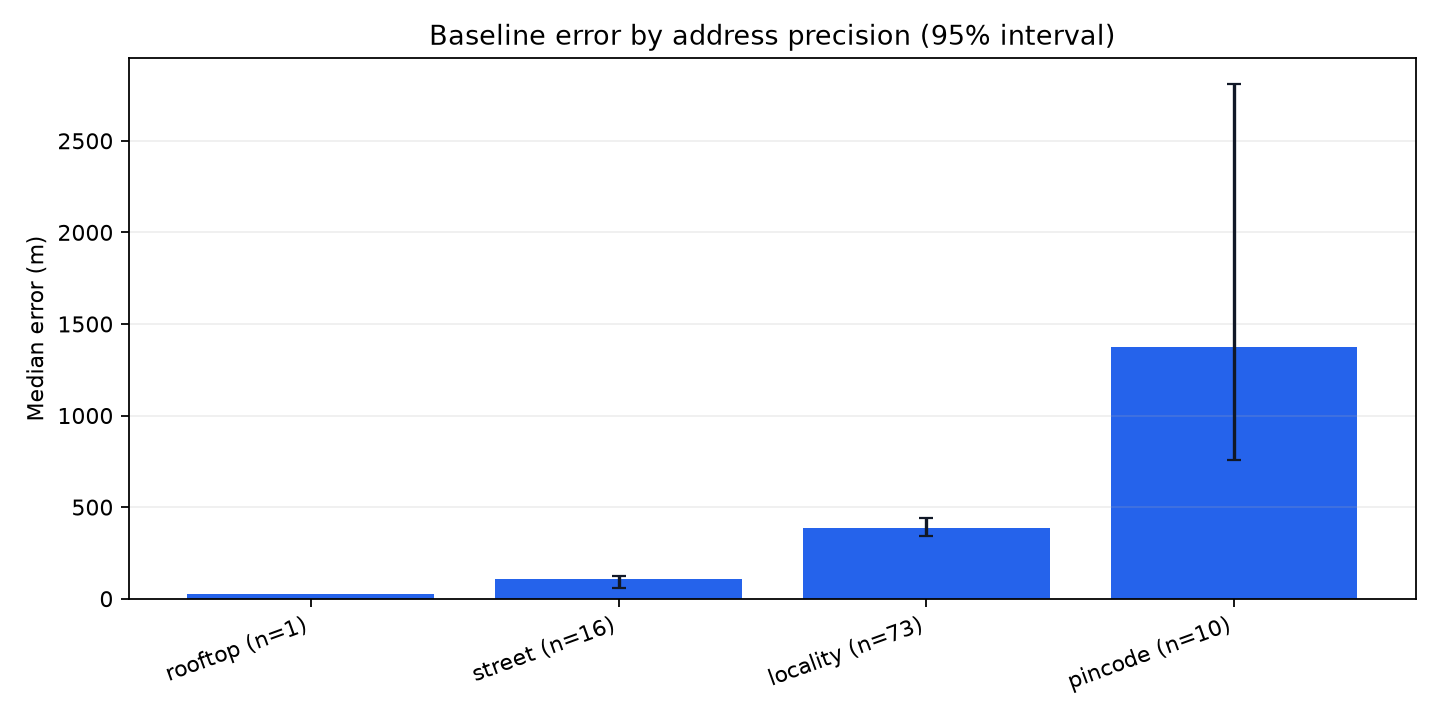

In [2]:
base = pd.read_csv(R/'baseline_scores.csv')
display(base[['dimension','segment','n','median_error_m','median_ci95_low_m','median_ci95_high_m','p90_error_m','share_within_100m']].round(2))
display(Image(str(R/'baseline_by_precision.png'), width=520))

## 2. Visit evidence and the fake-visit stress test
Each visit becomes one trusted point with a role and an uncertainty. Synthetic home check-ins, tea-stall stops and a rogue agent were
injected and every safeguard was recomputed from the contaminated data.

evidence_role,contact_at_address,failed_search,structure_only,historical_structure,contact_elsewhere
visits,2007,1438,1432,455,246


,scenario,method,affected_addresses,reported_pins,abstentions,median_pin_shift_m,p90_pin_shift_m,median_error_after_m
0,home_checkin,"independent-agent cluster, may abstain",38,16,22,0.00,3.52,7.12
1,home_checkin,"mean, high-trust injection",38,38,0,2502.68,3771.15,2507.62
2,home_checkin,"median, high-trust injection",38,38,0,3290.75,4102.14,3293.63
3,home_checkin,"median, recomputed safeguards",38,38,0,0.00,3721.97,9.90
4,rogue_agent,"independent-agent cluster, may abstain",16,9,7,0.00,23.32,8.77
5,rogue_agent,"mean, high-trust injection",16,16,0,2668.44,4934.41,2657.99
6,rogue_agent,"median, high-trust injection",16,16,0,3076.07,5976.11,3073.70
7,rogue_agent,"median, recomputed safeguards",16,16,0,0.00,2544.75,9.00
8,tea_stall,"independent-agent cluster, may abstain",38,16,22,0.00,2.50,7.12
9,tea_stall,"mean, high-trust injection",38,38,0,4128.67,5247.44,4129.88


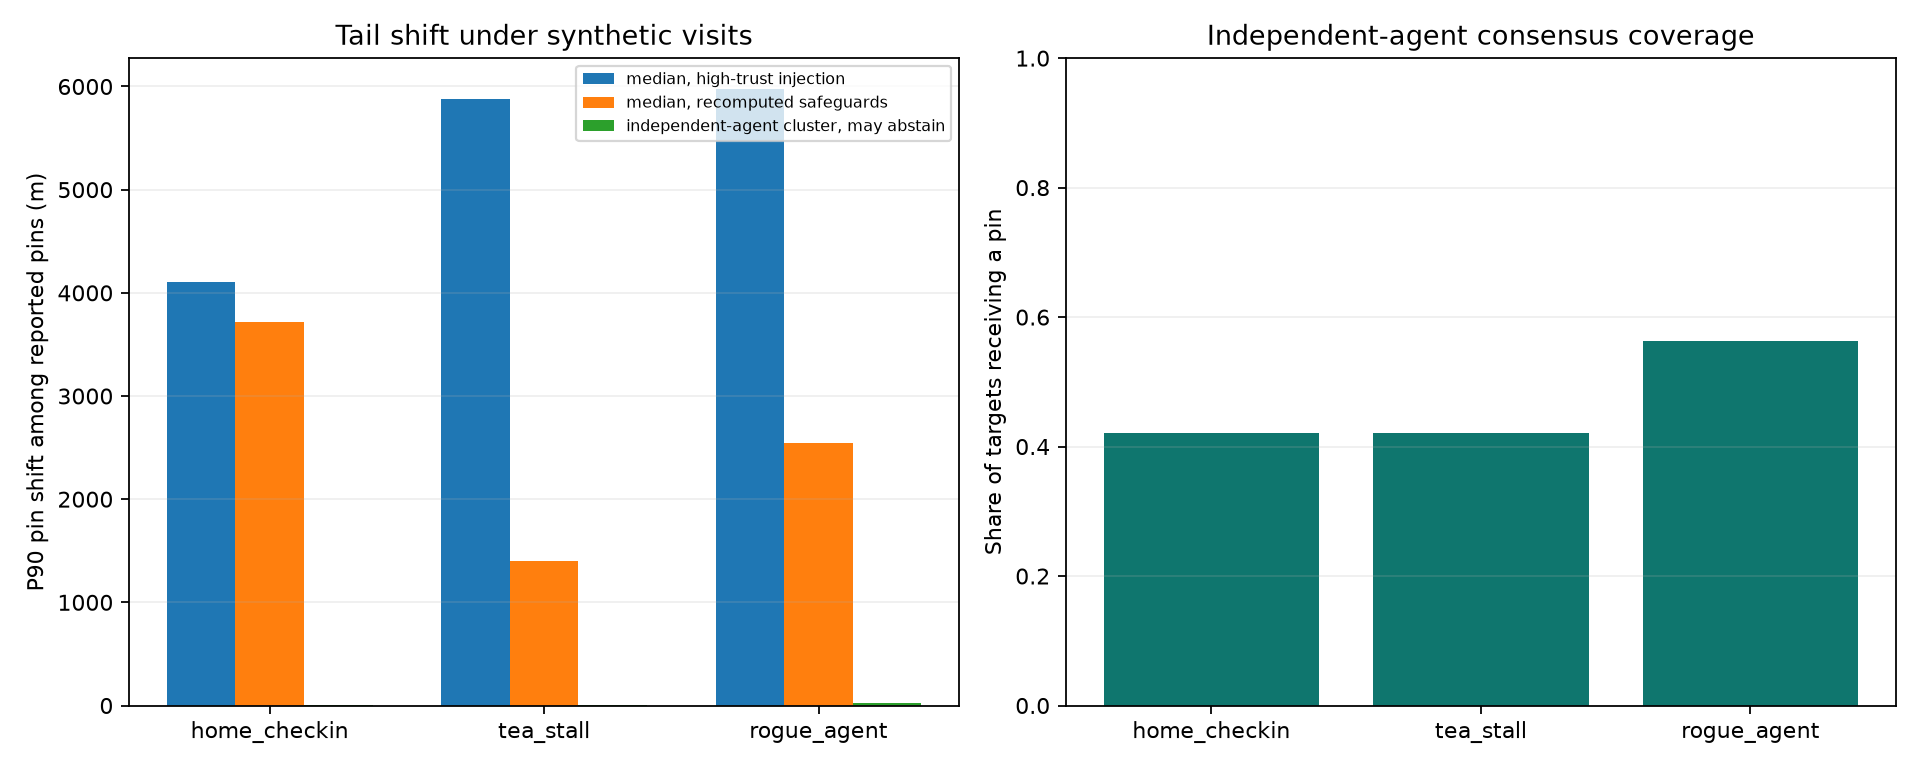

In [3]:
ev = pd.read_csv('outputs/evidence.csv')
display(ev.evidence_role.value_counts().rename('visits').to_frame().T)
display(pd.read_csv(R/'integrity_stress_summary.csv').round(2))
display(Image(str(R/'integrity_stress_pin_shift.png'), width=620))

## 3. Pin model

## 1. Address parsing coverage

In [4]:
f = pd.read_csv(R/'address_features.csv')
cov = f[['pincode_text','loc_id','cross','main','gali','block','road','ward','building','lm_type']].notna().mean().round(3)
display(cov.rename('share of addresses with the field').to_frame())
display(f.lm_type.value_counts().rename('landmark type').to_frame().T)

,share of addresses with the field
pincode_text,0.919
loc_id,0.903
cross,0.267
main,0.266
gali,0.275
block,0.293
road,0.293
ward,0.083
building,0.076
lm_type,0.712


lm_type,govt_school,ganesha_temple,bus_stop,ration_shop,masjid,hanuman_temple,medical_store,milk_dairy,church,community_hall,water_tank,post_office,park,petrol_bunk
landmark type,192,190,190,171,169,160,159,156,138,138,121,96,88,84


## 2. What each layer adds (ablation ladder)

In [5]:
ab = pd.read_csv(R/'pin_model_ablation.csv')
display(ab.round(1))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
y = np.arange(len(ab))[::-1]
ax[0].barh(y, ab.all100_median, color='#3b6ea5'); ax[0].set_yticks(y); ax[0].set_yticklabels(ab.variant, fontsize=8)
ax[0].set_xlabel('median error, 100 surveyed (m)'); ax[0].set_title('Median')
ax[1].barh(y, ab.all100_p90, color='#c26a3d'); ax[1].set_yticks([]); ax[1].set_xlabel('90th percentile error (m)'); ax[1].set_title('P90')
plt.tight_layout(); plt.savefig(R/'pin_model_ablation.png', dpi=130); plt.show()

,variant,dev85_median,dev85_p90,test15_median,test15_p90,all100_median,all100_p90,within50,within100,within250
0,0 old geocoder only,362.9,747.7,455.5,2845.2,376.4,839.2,0.0,0.1,0.4
1,1 + own visit evidence,117.7,615.6,154.3,2477.0,125.9,625.1,0.4,0.5,0.6
2,2 + locality group/centroid,98.6,536.9,142.6,2577.8,118.8,550.0,0.4,0.5,0.6
3,3 + neighbours on same street key,68.7,534.1,69.4,2577.8,69.0,550.0,0.4,0.5,0.7
4,4 + street-number grid regression,33.3,500.5,58.3,2577.8,37.0,537.4,0.5,0.6,0.8
5,5 + landmark groups and POIs (full model),38.5,351.4,68.3,2472.6,45.7,368.6,0.5,0.6,0.9


C:\Users\ASUS\AppData\Local\Temp\ipykernel_38012\1405834359.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.savefig(R/'pin_model_ablation.png', dpi=130); plt.show()


## 3. Accuracy on the 100 surveyed addresses (out-of-fold)

`dev85` = development folds 1-5, `test15` = official-test fold 0. Surveyed addresses are about 49% visited / 51% unvisited, so the overall number mixes two very different populations - see section 4.

In [6]:
sc = pd.read_csv(R/'pin_model_scores.csv')
display(sc[['dimension','segment','n','median_error_m','median_ci95_low_m','median_ci95_high_m','p90_error_m','share_within_50m','share_within_100m','share_within_250m']].round(2))

,dimension,segment,n,median_error_m,median_ci95_low_m,median_ci95_high_m,p90_error_m,share_within_50m,share_within_100m,share_within_250m
0,overall,all,100,45.68,27.76,74.33,368.57,0.51,0.65,0.86
1,precision,locality,73,47.33,22.79,96.96,294.67,0.51,0.63,0.89
2,precision,pincode,10,884.82,9.17,2416.43,3963.04,0.40,0.40,0.40
3,precision,rooftop,1,25.59,NaN,NaN,25.59,1.00,1.00,1.00
4,precision,street,16,41.53,25.95,72.08,87.82,0.56,0.88,1.00
5,town_id,T1,33,34.14,22.79,70.90,334.40,0.58,0.70,0.85
6,town_id,T2,29,69.37,19.21,111.00,250.68,0.45,0.66,0.90
7,town_id,T3,38,51.75,19.29,112.31,618.78,0.50,0.61,0.84
8,split,test,15,68.27,28.24,161.10,2472.61,0.47,0.73,0.80
9,split,train,66,73.20,31.97,126.49,461.71,0.45,0.56,0.83


In [7]:
oof = pd.read_csv(R/'pin_model_oof_errors.csv')
base = pd.read_csv('data/baseline_geocodes.csv').set_index('address_id'); sv = pd.read_csv('data/surveyed_addresses.csv').set_index('address_id')
old = np.hypot(base.geocoder_x - sv.surveyed_x, base.geocoder_y - sv.surveyed_y).loc[oof.address_id].values
fig, ax = plt.subplots(figsize=(6.2, 4))
for e, lab, c in [(old, 'old geocoder', '#999999'), (oof.error_m.values, 'pin model (out-of-fold)', '#3b6ea5')]:
    s = np.sort(e); ax.plot(s, np.arange(1, len(s)+1)/len(s), label=lab, color=c, lw=2)
ax.set_xscale('log'); ax.set_xlabel('distance error (m, log scale)'); ax.set_ylabel('share of addresses'); ax.grid(alpha=.3); ax.legend()
ax.set_title('Error distribution, 100 surveyed addresses'); plt.tight_layout(); plt.savefig(R/'pin_model_error_cdf.png', dpi=130); plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38012\2426858270.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.set_title('Error distribution, 100 surveyed addresses'); plt.tight_layout(); plt.savefig(R/'pin_model_error_cdf.png', dpi=130); plt.show()


## 4. The harder question: addresses with NO visit

The hide-and-predict check hides each visited address's own visit evidence and asks the model to recover the visit pin from text, neighbours, landmarks and the old pin. It uses 1,231 addresses and **no surveyed truth**, so it is both large and independent of the 100-address survey. This is the realistic number for the ~57% of addresses that have no usable visit.

In [8]:
hp = pd.read_csv(R/'hide_and_predict.csv')
tab = pd.DataFrame({'old geocoder': hp.err_old.describe(percentiles=[.5,.9])[['50%','90%']], 'pin model': hp.err_model.describe(percentiles=[.5,.9])[['50%','90%']]}).T
tab['within 100 m'] = [(hp.err_old<=100).mean(), (hp.err_model<=100).mean()]; display(tab.round(2))
display(hp.groupby('precision')[['err_old','err_model']].median().round(0).join(hp.groupby('precision').size().rename('n')))
display(hp.groupby('method_used').agg(n=('err_model','size'), model_median=('err_model','median'), old_median=('err_old','median')).round(0))

,50%,90%,within 100 m
old geocoder,320.54,797.19,0.12
pin model,126.33,606.91,0.42


,err_old,err_model,n
precision,,,
locality,354.0,139.0,891
pincode,1352.0,1369.0,94
rooftop,18.0,20.0,26
street,121.0,73.0,220


,n,model_median,old_median
method_used,,,
baseline,210,110.0,133.0
blend,64,82.0,250.0
landmark_group,79,172.0,367.0
landmark_poi,127,213.0,332.0
locality_centroid,93,1358.0,1356.0
street_grid,589,89.0,317.0
street_key,69,92.0,396.0


## 5. Is `raw_spread` honest? (input to Task 4's calibrated radii)

In [9]:
oofm = oof.merge(pd.read_csv('outputs/pins.csv')[['address_id','raw_spread','method_used']], on='address_id')
hp2 = hp.copy()
for name, e, s in [('surveyed OOF (n=%d)' % len(oofm), oofm.error_m, oofm.raw_spread), ('hide-and-predict (n=%d)' % len(hp2), hp2.err_model, hp2.raw_spread)]:
    r = e / s
    print(f'{name:30s} Spearman(raw_spread, error) = {pd.Series(s.values).corr(pd.Series(e.values), method="spearman"):.2f}; '
          f'share of errors within 1.18x / 2.15x raw_spread = {(r<=1.177).mean():.2f} / {(r<=2.146).mean():.2f} (Gaussian ideal 0.50 / 0.90)')
fig, ax = plt.subplots(figsize=(5.2, 4))
ax.scatter(hp2.raw_spread, hp2.err_model, s=6, alpha=.35, color='#3b6ea5'); lim = [10, 4000]; ax.plot(lim, lim, 'k--', lw=1, label='error = spread')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('raw_spread (m)'); ax.set_ylabel('actual error (m)'); ax.legend(); ax.set_title('hide-and-predict'); plt.tight_layout(); plt.savefig(R/'pin_model_spread_vs_error.png', dpi=130); plt.show()

surveyed OOF (n=100)           Spearman(raw_spread, error) = 0.88; share of errors within 1.18x / 2.15x raw_spread = 0.85 / 0.96 (Gaussian ideal 0.50 / 0.90)
hide-and-predict (n=1231)      Spearman(raw_spread, error) = 0.69; share of errors within 1.18x / 2.15x raw_spread = 0.73 / 0.91 (Gaussian ideal 0.50 / 0.90)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_38012\3865128299.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('raw_spread (m)'); ax.set_ylabel('actual error (m)'); ax.legend(); ax.set_title('hide-and-predict'); plt.tight_layout(); plt.savefig(R/'pin_model_spread_vs_error.png', dpi=130); plt.show()


## 6. Where it fails

In [10]:
ad = pd.read_csv('data/addresses.csv').set_index('address_id')
w = oofm.set_index('address_id').join(ad[['address_text']]).sort_values('error_m', ascending=False).head(10)
display(w[['precision','error_m','raw_spread','method_used','address_text']].round(0))

,precision,error_m,raw_spread,method_used,address_text
address_id,,,,,
AD001909,pincode,4740.0,1310.0,locality_centroid,#448 6th cr 8th mn kaveripura - 960104
AD001146,pincode,3877.0,2589.0,locality_centroid,"No. 122, nr Mosque, Navanagara East"
AD000170,locality,1791.0,820.0,baseline,"Blk F, Rd 6, Green Park Layout, Navanagara East - 980301"
AD000141,pincode,1113.0,1321.0,locality_centroid,"Gali No. 4, Ward 1, Devgarh Nagar - 970202"
AD001786,locality,1087.0,768.0,landmark_group,"Sai Residency, Blk A, Rd 3, Doodh Dairy ke bagal mein, Green Park Layout, Navanagara East - 983001"
AD001987,pincode,1052.0,1441.0,locality_centroid,"103/2, Gali No. 1, मस्जिद के पास, Devgarh Nagar - 970202"
AD001999,pincode,956.0,1301.0,locality_centroid,"#284, 3RD CROSS, 3RD MAIN, CLOSE TO POST OFFICE, KAVERIPURA - 960104"
AD002295,pincode,814.0,1737.0,locality_centroid,"Shanti Kunj, Blk A, Rd 4, Navanagara East - 980301"
AD001536,locality,535.0,817.0,baseline,no. 79 railway colony navanagara east - 980302


**Reading the failures.** The worst addresses are almost all *pincode-tier addresses whose text names no locality*. The pincode leaves 3-5 candidate localities about 1.4 km apart, nothing in the text separates them (street numbers repeat across localities; only T2 wards are locality-specific), and the old pin is already the pincode centroid. No text model can fix that; the model keeps close to the old pin there and reports a wide `raw_spread`, so the visit planner should send these addresses to *verify first*. One confirmed visit resolves them (the visit becomes the pin), which is the learning loop doing its job.

## 7. Limits to state honestly
- 100 surveyed addresses is small; intervals are in `pin_model_scores.csv`. Strata below 10 are not interpretable.
- The visit-derived labels used for tuning are not survey truth (they agree with it to a median of about 8 m where both exist).
- Surveyed truth covers residences only; office/native-village pins are unvalidated.
- The official-test fold was seen during exploratory analysis; freeze the method before claiming a blind result.

## 4. Calibration, confidence tiers and directions

## 1. Does a '90%' radius contain the truth about 90% of the time?

In [11]:
cov = pd.read_csv(R/'calibration_coverage.csv')
show = cov[cov.nominal.isin([0.5, 0.9])].copy()
display(show[['dimension','segment','n','nominal','coverage','ci95_low','ci95_high','median_radius_90','median_error']].round(3))

,dimension,segment,n,nominal,coverage,ci95_low,ci95_high,median_radius_90,median_error
0,overall,all surveyed,100,0.5,0.590,0.492,0.681,145.578,45.676
2,overall,all surveyed,100,0.9,0.910,0.838,0.952,145.578,45.676
3,group,noloc,6,0.5,0.667,0.300,0.903,1806.910,1082.123
5,group,noloc,6,0.9,0.667,0.300,0.903,1806.910,1082.123
6,group,novisit,51,0.5,0.647,0.510,0.764,347.459,110.999
8,group,novisit,51,0.9,0.941,0.841,0.980,347.459,110.999
9,group,visit,43,0.5,0.512,0.368,0.654,24.580,10.508
11,group,visit,43,0.9,0.907,0.784,0.963,24.580,10.508
12,town,T1,33,0.5,0.576,0.408,0.728,135.881,34.138
14,town,T1,33,0.9,0.848,0.691,0.933,135.881,34.138


In [12]:
rel = pd.read_csv(R/'calibration_reliability.csv')
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.plot([0,1],[0,1],'k--',lw=1,label='perfect')
for name, g in rel.groupby('curve'):
    ax.plot(g.nominal, g.observed, marker='o', ms=4, label=f'{name} (n={int(g.n.iloc[0])})')
ax.set_xlabel('nominal coverage'); ax.set_ylabel('observed coverage'); ax.grid(alpha=.3); ax.legend(fontsize=7, loc='upper left')
ax.set_title('Reliability of the confidence radii'); plt.tight_layout(); plt.savefig(R/'calibration_reliability.png', dpi=140); plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38012\1167337464.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.set_title('Reliability of the confidence radii'); plt.tight_layout(); plt.savefig(R/'calibration_reliability.png', dpi=140); plt.show()


Points above the diagonal are conservative (radius bigger than needed); below would be over-confident. Small groups wobble because of sample size, not necessarily miscalibration - the intervals above say how much.

## 2. Calibration by town and by the old geocoder's precision tier (90% radius)

In [13]:
sub = cov[(cov.nominal==0.9) & cov.dimension.isin(['town','old_geocoder_tier'])]
fig, ax = plt.subplots(figsize=(6.5, 3.2))
y = np.arange(len(sub))[::-1]
ax.errorbar(sub.coverage, y, xerr=[sub.coverage-sub.ci95_low, sub.ci95_high-sub.coverage], fmt='o', color='#3b6ea5', capsize=3)
ax.axvline(0.9, color='k', ls='--', lw=1); ax.set_yticks(y); ax.set_yticklabels([f'{d}: {s} (n={n})' for d,s,n in zip(sub.dimension, sub.segment, sub.n)], fontsize=8)
ax.set_xlabel('observed coverage of the 90% radius (95% Wilson interval)'); ax.set_xlim(0.2,1.02); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(R/'calibration_by_segment.png', dpi=140); plt.show()
display(sub[['dimension','segment','n','coverage','ci95_low','ci95_high']].round(3))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38012\92613531.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.savefig(R/'calibration_by_segment.png', dpi=140); plt.show()


,dimension,segment,n,coverage,ci95_low,ci95_high
14,town,T1,33,0.848,0.691,0.933
17,town,T2,29,0.966,0.828,0.994
20,town,T3,38,0.921,0.792,0.973
23,old_geocoder_tier,locality,73,0.932,0.849,0.970
26,old_geocoder_tier,pincode,10,0.800,0.490,0.943
29,old_geocoder_tier,rooftop,1,1.000,0.207,1.000
32,old_geocoder_tier,street,16,0.875,0.640,0.965


Intervals for small strata (rooftop n=1, pincode n=10, the `noloc` group n=6) are wide and are **not** evidence either way.
Pincode-tier addresses with no locality in the text are the hard case; the model's radius for them is already in the kilometre range and their tier is always `low`.

## 3. Confidence tiers: do they separate easy from hard addresses?

In [14]:
tq = pd.read_csv(R/'confidence_tier_quality.csv'); display(tq.round(2))
pred = pd.read_csv('outputs/predictions.csv')
display(pred.groupby('confidence_tier').agg(addresses=('address_id','size'), median_radius_90=('radius_90','median'), median_location_confidence=('location_confidence','median')).round(2))
display(pred.groupby(['confidence_tier','suggested_action']).size().rename('addresses').to_frame())

,tier,n,median_err,within_100,within_250
0,high,39,9.57,0.97,1.0
1,low,35,192.45,0.20,0.6
2,medium,26,45.68,0.77,1.0


,addresses,median_radius_90,median_location_confidence
confidence_tier,,,
high,1106,21.20,0.98
low,1034,547.15,0.23
medium,740,157.25,0.77


,,addresses
confidence_tier,suggested_action,
high,VISIT_NOW,1106
low,VERIFY_FIRST,1034
medium,VISIT_WITH_DIRECTIONS,740


Rule: **high** = 90% radius <= 60 m (visit now); **medium** = <= 300 m (visit with directions); **low** = above that (verify first, never mark 'not traceable' on this basis).
On the surveyed addresses the tiers separate cleanly (accuracy columns above).

## 4. What drives the radius

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
order = pred.groupby('method_used').radius_90.median().sort_values().index
data = [np.log10(pred[pred.method_used==m].radius_90) for m in order]
ax.boxplot(data, vert=False, showfliers=False); ax.set_yticklabels([f'{m} (n={int((pred.method_used==m).sum())})' for m in order])
ax.set_xlabel('log10 of 90% radius (m)'); plt.tight_layout(); plt.savefig(R/'radius_by_method.png', dpi=140); plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38012\1962587679.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, showfliers=False); ax.set_yticklabels([f'{m} (n={int((pred.method_used==m).sum())})' for m in order])


C:\Users\ASUS\AppData\Local\Temp\ipykernel_38012\1962587679.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.set_xlabel('log10 of 90% radius (m)'); plt.tight_layout(); plt.savefig(R/'radius_by_method.png', dpi=140); plt.show()


## 5. Directions

In [16]:
chk = pd.read_csv(R/'directions_checks.csv'); display(chk.round(3).T)
display(pred.sample(10, random_state=4)[['address_id','confidence_tier','radius_90','directions']])

,0
share_with_a_landmark,0.994
surveyed_with_address_landmark,72.000
address_landmark_within_300m_of_truth,0.625
address_landmark_within_300m_of_our_pin,0.639
same_landmark_chosen_for_pin_and_truth,0.972
share_directions_needing_locality_disambiguation,0.055


,address_id,confidence_tier,radius_90,directions
2648,AD002857,low,727.1,"APPROXIMATE (within ~730 m): 250 m SE of Masjid; also 350 m NW of Medical Store; also 400 m E of Ganesh Temple. Address: Block C, Road 2. Verify with a loca..."
2165,AD002342,low,605.9,APPROXIMATE (within ~610 m): 60 m SW of Govt School; also 300 m W of Water Tank; also 350 m NW of Park. Verify with a local before walking in.
2638,AD002847,medium,288.1,"Likely area (within ~290 m): 150 m S of Medical Store. Address: Block C, Road 1"
1109,AD001196,low,1932.4,"APPROXIMATE (within ~1930 m): 1150 m NW of Community Hall; also 450 m SW of Hanuman Temple; also 500 m S of Medical Store. Address: 9th Cross, 2nd Main. Ver..."
2727,AD002942,medium,213.9,Likely area (within ~210 m): 160 m N of Medical Store (Gandhi Basti side); also 400 m NE of Govt School. Address: Gali 9
2489,AD002691,high,50.7,"140 m NE of Ration Shop; also 400 m E of Medical Store; also 400 m E of Community Hall. Address: 10th Cross, 7th Main"
78,AD000084,low,325.8,"APPROXIMATE (within ~330 m): 150 m S of Masjid; also 300 m W of Ganesh Temple; also 450 m SE of Hanuman Temple. Address: Block B, Road 4. Verify with a loca..."
2252,AD002436,medium,248.4,"Likely area (within ~250 m): 200 m NE of Community Hall; also 350 m NW of Govt School; also 400 m SW of Petrol Bunk. Address: Gali 6, Ward 8"
2267,AD002453,high,19.1,"130 m NW of Church; also 190 m NE of Milk Dairy; also 250 m NE of Govt School. Address: Gali 8, Ward 11"
1993,AD002157,high,41.4,"80 m SE of Bus Stop; also 250 m N of Govt School; also 250 m N of Church. Address: Block D, Road 4"


Directions are plain-text templates built from the nearest landmarks to the pin (distance rounded, 8-point compass), with the address's own landmark first when one of that type is nearby, and the locality named when the same landmark name exists nearby. They need no network.
`test_task4.py` checks that 597 of 598 sampled direction clauses reproduce the distance and bearing from the stated landmark to the pin.
**Assumption to confirm with CN:** local x points east and y north (the source gives no CRS); flip `AXES` in `confidence_directions.py` if not.

## 6. Hand-off to Problem Statement 2

In [17]:
ps2 = pd.read_csv('outputs/ps2_location_confidence.csv'); display(ps2.head(6)); display(ps2.ps2_guidance.value_counts().to_frame())

,address_id,location_confidence,p_within_250m,radius_90_m,confidence_tier,hard_to_find_flag,reason_codes,ps2_guidance
0,AD000001,0.977,0.977,16.2,high,0,CONFIRMED_BY_FIELD_VISIT,LOCATION_CONFIRMED_OR_RELIABLE: a failed visit is informative
1,AD000002,0.977,0.977,24.1,high,0,CONFIRMED_BY_FIELD_VISIT,LOCATION_CONFIRMED_OR_RELIABLE: a failed visit is informative
2,AD000003,0.062,0.279,1224.4,low,1,INFERRED_FROM_STREET_NEIGHBOURS,LOCATION_UNRESOLVED: do not treat a failed visit here as evidence the address is invalid
3,AD000004,0.308,0.720,450.2,low,1,INFERRED_FROM_STREET_NEIGHBOURS,LOCATION_UNRESOLVED: do not treat a failed visit here as evidence the address is invalid
4,AD000005,0.202,0.605,579.4,low,1,INFERRED_FROM_LANDMARK,LOCATION_UNRESOLVED: do not treat a failed visit here as evidence the address is invalid
5,AD000007,0.373,0.780,392.0,low,1,INFERRED_FROM_STREET_NEIGHBOURS,LOCATION_UNRESOLVED: do not treat a failed visit here as evidence the address is invalid


,count
ps2_guidance,
LOCATION_CONFIRMED_OR_RELIABLE: a failed visit is informative,1106
LOCATION_UNRESOLVED: do not treat a failed visit here as evidence the address is invalid,1033
LOCATION_APPROXIMATE: a failed visit is weak evidence; retry with directions,741
